In [1]:
import numpy as np

from rustic_py import SourceSpec, GraphSpec, LowPassFilter, HighPassFilter, GainFilter, Compressor, Tremolo, DelayFilter, PanFilter, Clipper, BandPass
from rustic_dev import spectrogram, plot_waveform, plot_diff, freq_compare, freq_display, play
from rustic_dev import mix_to_mono, normalize, diff, rms, rms_compare

Rendered 30870 samples at 44100 Hz (0.70s), shape=(30870, 2)


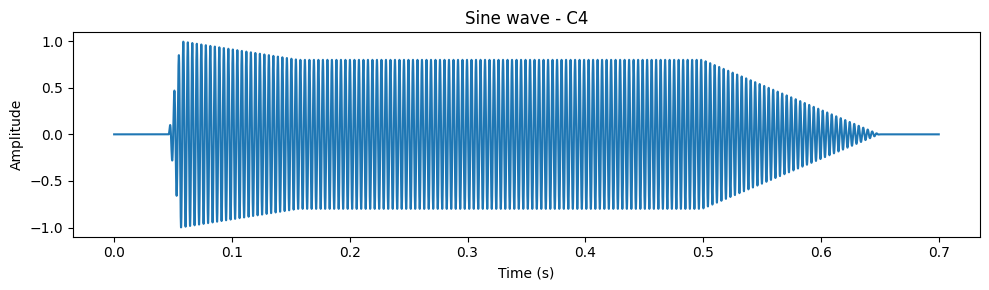

/home/minigrim0/Documents/code/rust/rustic/dev/.venv/lib/python3.14/site-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


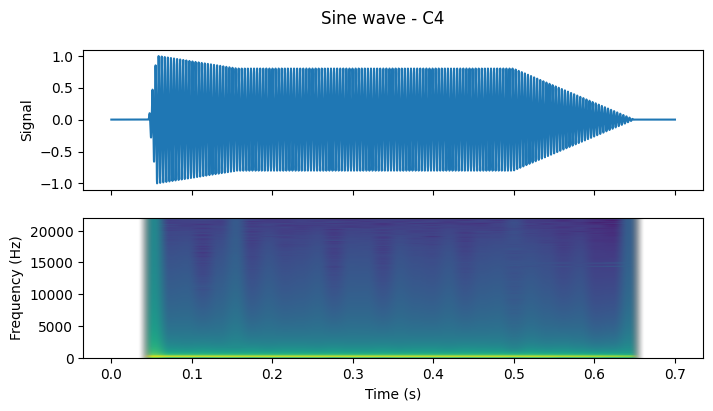

In [2]:
spec = GraphSpec(
  note=60,       # C4
  note_on=0.05,
  note_off=0.5,
  duration=0.7,
  source=SourceSpec(waveform="sine", attack=0.01, decay=0.1, sustain=0.8, release=0.15),
)

audio = spec.render()
print(f"Rendered {audio.shape[0]} samples at 44100 Hz ({audio.shape[0]/44100:.2f}s), shape={audio.shape}")

plot_waveform(audio, 44100, title="Sine wave - C4")
spectrogram(audio, 44100, title="Sine wave - C4")

## Filtered Vs dry signal

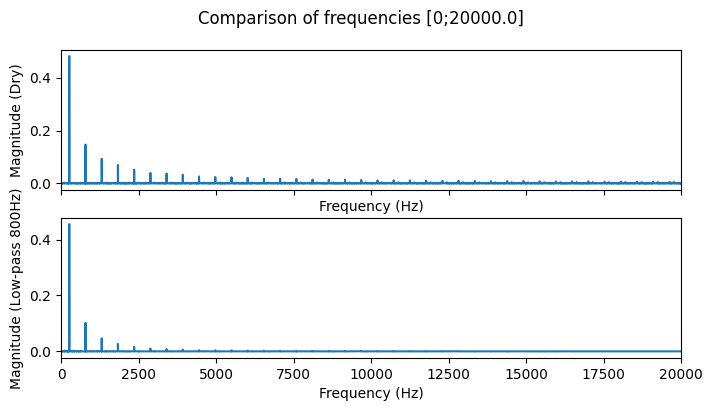

In [3]:
filtered = GraphSpec(
    note=60,
    note_on=0.05,
    note_off=0.5,
    duration=0.7,
    source=SourceSpec(waveform="square", attack=0.01, decay=0.1, sustain=0.8, release=0.15),
    filters=[LowPassFilter(cutoff_frequency=800.0)],
).render()                                                                                                                                                                                                                                                          

dry = GraphSpec(
    note=60,
    note_on=0.05,
    note_off=0.5,
    duration=0.7,
    source=SourceSpec(waveform="square", attack=0.01, decay=0.1, sustain=0.8, release=0.15),
).render()

freq_compare(mix_to_mono(dry), mix_to_mono(filtered), 44100, sig1_name="Dry", sig2_name="Low-pass 800Hz")
play(filtered, 44100)

## Regression test

In [4]:
tests = [
    ("note out of range",   lambda: GraphSpec(note=200, note_on=0.0, note_off=0.5, duration=0.7, source=SourceSpec())),
    ("note_off < note_on",  lambda: GraphSpec(note=60, note_on=0.5, note_off=0.1, duration=0.7, source=SourceSpec())),
    ("duration < note_off", lambda: GraphSpec(note=60, note_on=0.0, note_off=0.5, duration=0.3, source=SourceSpec())),
    ("bad waveform",        lambda: SourceSpec(waveform="theremin")),
    ("sustain > 1",         lambda: SourceSpec(sustain=2.0)),
    ("cutoff out of range", lambda: LowPassFilter(cutoff_frequency=99999.0)),
    ("compressor ratio > 20", lambda: Compressor(ratio=100.0)),
]

for label, fn in tests:
    try:
        fn()
        print(f"  MISSING validation: {label}")
    except ValueError as e:
        print(f"  OK  {label}: {e}")

  OK  note out of range: note must be 0–127, got 200
  OK  note_off < note_on: note_off=0.1 must be >= note_on=0.5
  OK  duration < note_off: duration=0.3 must be >= note_off=0.5
  OK  bad waveform: waveform must be one of ['sine', 'square', 'saw', 'triangle', 'whitenoise', 'pinknoise', 'blank'], got 'theremin'
  OK  sustain > 1: sustain=2.0 must be in [0.0, 1.0]
  OK  cutoff out of range: cutoff_frequency=99999.0 must be <= 20000.0
  OK  compressor ratio > 20: ratio=100.0 must be <= 20.0


## Frequency comparison for different shapes

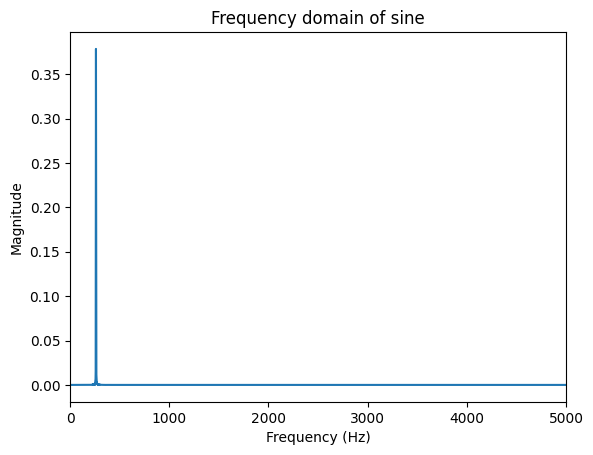

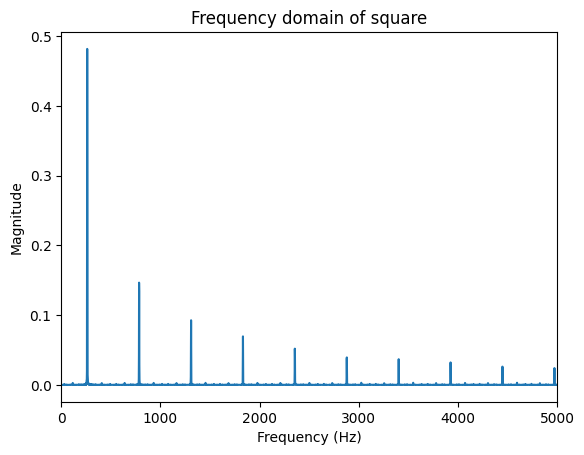

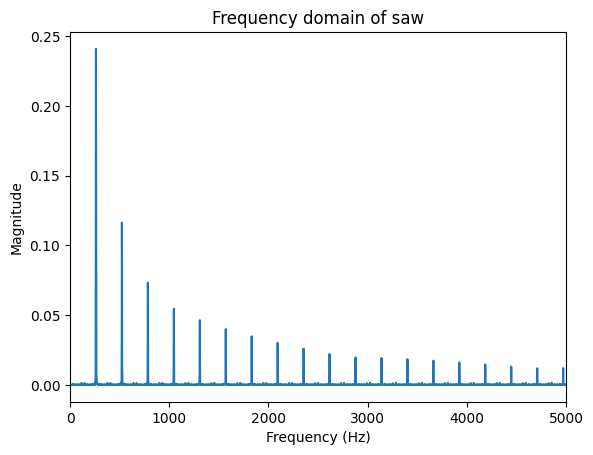

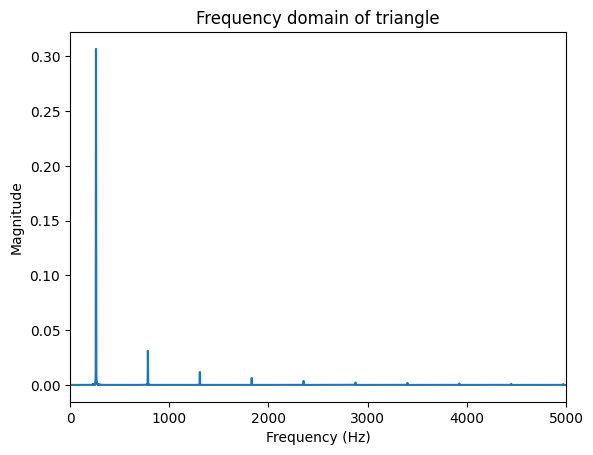

In [6]:
notes = [
    ("sine",      60),
    ("square",    60),
    ("saw",       60),
    ("triangle",  60),
]

for waveform, note in notes:
    audio = GraphSpec(
        note=note, note_on=0.05, note_off=0.5, duration=0.7,
        source=SourceSpec(waveform=waveform, attack=0.01, decay=0.1, sustain=0.8, release=0.15),
    ).render()
    freq_display(mix_to_mono(audio), 44100, sig_name=waveform, focus_window=(0, 5000))

## ADSR Envelope shapes

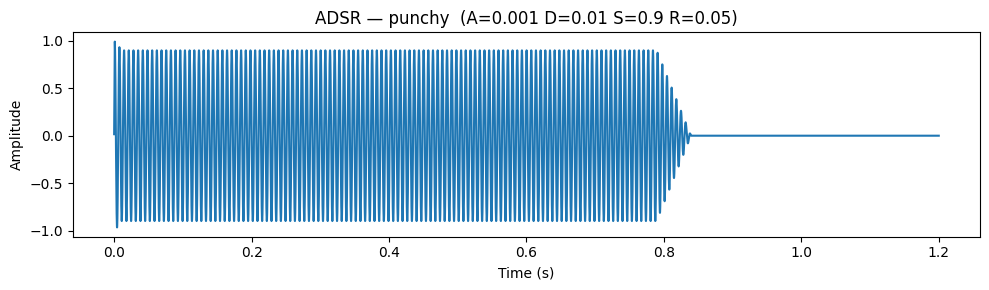

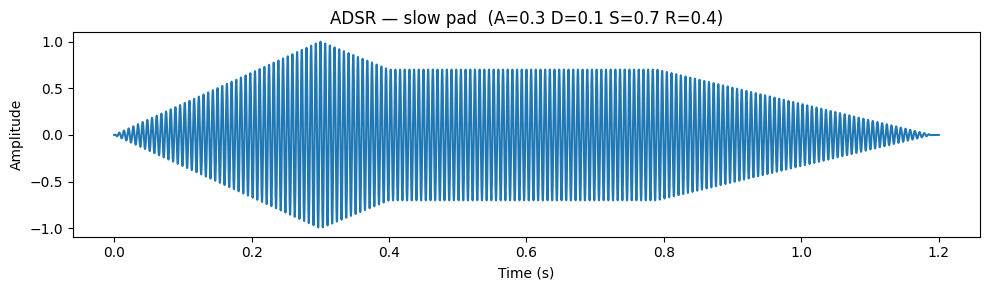

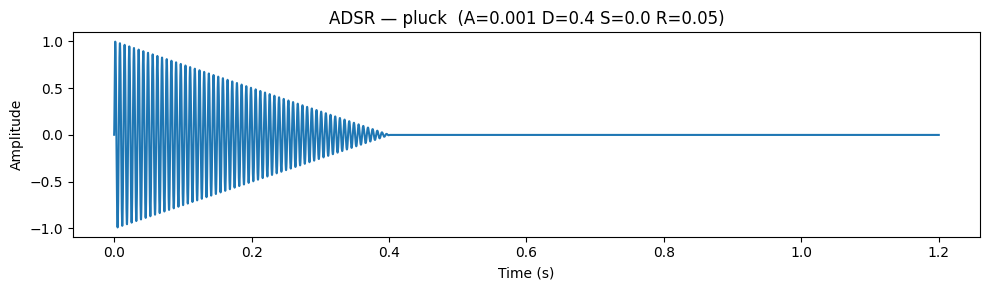

In [12]:
for attack, decay, sustain, release, label in [
    (0.001, 0.01, 0.9, 0.05, "punchy"),
    (0.3,   0.1,  0.7, 0.4,  "slow pad"),
    (0.001, 0.4,  0.0, 0.05, "pluck"),
]:
    audio = GraphSpec(
        note=50, note_on=0.0, note_off=0.8, duration=1.2,
        source=SourceSpec(waveform="sine", attack=attack, decay=decay, sustain=sustain, release=release),
    ).render()
    plot_waveform(audio, 44100, title=f"ADSR — {label}  (A={attack} D={decay} S={sustain} R={release})")
    play(audio, 44100)

## RMS

In [13]:
dry   = GraphSpec(note=60, note_on=0.0, note_off=0.5, duration=0.7, source=SourceSpec()).render()
quiet = GraphSpec(note=60, note_on=0.0, note_off=0.5, duration=0.7, source=SourceSpec(), filters=[GainFilter(factor=0.25)]).render()

ra, rb, ratio = rms_compare(dry, quiet)
print(f"Dry RMS:   {ra:.4f}")
print(f"Quiet RMS: {rb:.4f}")
print(f"Ratio:     {ratio:.2f}x  (expected ~4.0)")

Dry RMS:   0.0849
Quiet RMS: 0.0212
Ratio:     4.00x  (expected ~4.0)
